# 02 · Dynamic Station Clustering

## Objective
The main objective of this notebook is to re-execute the station clustering process using the newly cleaned dataset, which now excludes non-strict circular trips (trips with different start and end stations but unusually long durations relative to their distance). The goal is to determine if this final data cleaning phase has produced significant variations in the previously generated clusters.
1. Re-calculate dynamic time warping (DTW) matrices and perform hierarchical clustering on the refined dataset for both weekdays and weekends.
2. Compare the new cluster distributions and typologies against the pre-cleaning results to validate the effectiveness of removing non-strict circular trips and to obtain a more accurate representation of actual urban mobility patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
import os

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

## Load data

In this section, the distance matrices recalculated using the dataset with the removed trips will be loaded. Once again, the study will be divided into two distinct contexts: Weekdays and Weekends.

In [2]:
IMPUT_DIR = '../../data/processed/clustering_cleaned'

def load_clustering_data(day_type):
    """
    Loads the distance matrix, station IDs, and original signatures for a given day type 
    ('weekday' or 'weekend').
    """
    print(f"Loading data for: {day_type}")

    # Load matrix
    matrix_path = os.path.join(IMPUT_DIR, f'dtw_matrix_{day_type}.npy')
    dtw_matrix = np.load(matrix_path)

    # Load IDs
    ids_path = os.path.join(IMPUT_DIR, f'station_ids_{day_type}.npy')
    station_ids = np.load(ids_path)

    # Load original signatures
    sig_path = os.path.join(IMPUT_DIR, f'signatures_{day_type}.csv')
    df_signatures = pd.read_csv(sig_path, index_col=0)

    print(f"  Matrix Shape: {dtw_matrix.shape}")
    print(f"  Stations: {len(station_ids)}")
    
    return dtw_matrix, station_ids, df_signatures

dtw_matrix_weekday, station_ids_weekday, df_signatures_weekday = load_clustering_data('weekday')
dtw_matrix_weekend, station_ids_weekend, df_signatures_weekend = load_clustering_data('weekend')

Loading data for: weekday
  Matrix Shape: (2235, 2235)
  Stations: 2235
Loading data for: weekend
  Matrix Shape: (2234, 2234)
  Stations: 2234


## Weekday Analysis

The analysis begins by studying station behavior during weekdays. The primary objective is to differentiate between residential stations, workplace stations, and other potential specialized uses.

### Dendrogram

To determine the optimal number of clusters for dividing the stations, a dendrogram will be generated. In the analysis conducted prior to the removal of circular trips and outliers, the `'ward'` linkage method was used due to the `'average'` method's high sensitivity to those outliers. Since these outliers have now been removed, the `'average'` method will be tested again to see if it produces valid partitions. If the `'ward'` method still yields better results, it will remain the method of choice.

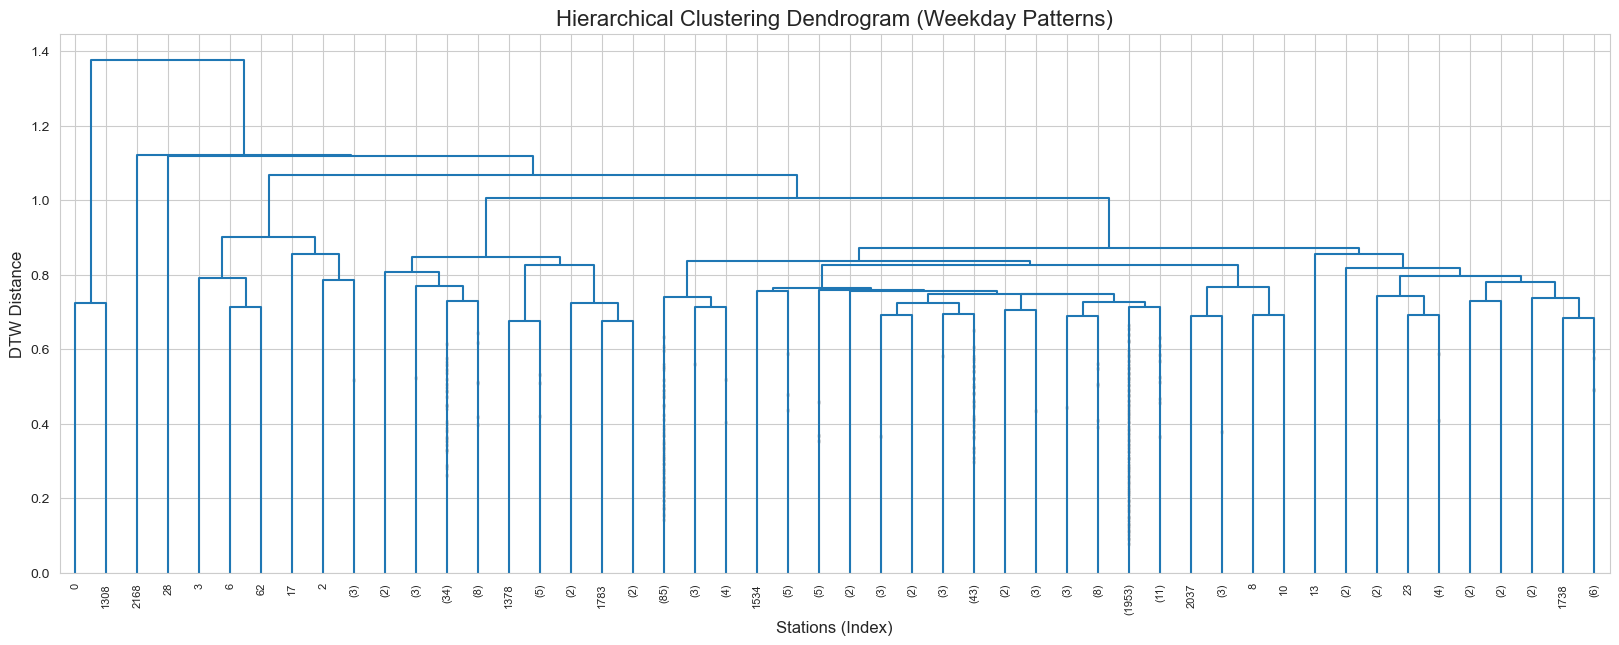

In [4]:
# Convert distance matrix to condensed form for hierarchical clustering
dist_condensed_weekday = squareform(dtw_matrix_weekday)

# Compute hierarchical clustering
Z_weekday = linkage(dist_condensed_weekday, method='average')

# Plot dendrogram
plt.figure(figsize=(20, 7))
plt.title('Hierarchical Clustering Dendrogram (Weekday Patterns)', fontsize=16)
plt.xlabel('Stations (Index)', fontsize=12)
plt.ylabel('DTW Distance', fontsize=12)

dendrogram(
    Z_weekday,
    leaf_rotation=90.,  
    leaf_font_size=8.,
    truncate_mode='lastp',
    p=50,
    show_contracted=True,
    color_threshold=0
)
plt.show()

Once again, the `'average'` method appears to produce overly complex divisions. The station distribution will be displayed using a cut at K = 6 (approx. 0.95) to verify if, similar to previous observations, it creates one massive group containing almost all stations while isolating single stations into their own clusters.

In [5]:
# Number of clusters
K_weekday = 6

print(f"Cutting tree to obtain {K_weekday} clusters\n")

cluster_labels_weekday = fcluster(Z_weekday, t=K_weekday, criterion='maxclust')

df_signatures_weekday['cluster_label'] = cluster_labels_weekday

print("Distribution of stations per cluster:")
print(df_signatures_weekday['cluster_label'].value_counts().sort_index())

Cutting tree to obtain 6 clusters

Distribution of stations per cluster:
cluster_label
1       2
2       8
3      58
4    2165
5       1
6       1
Name: count, dtype: int64


As anticipated, the same phenomenon occurs. The method groups practically all stations into one massive cluster and isolates slightly different stations into clusters containing only one or very few stations. Consequently, the `'ward'` method will be utilized, as it has proven to be significantly more effective.

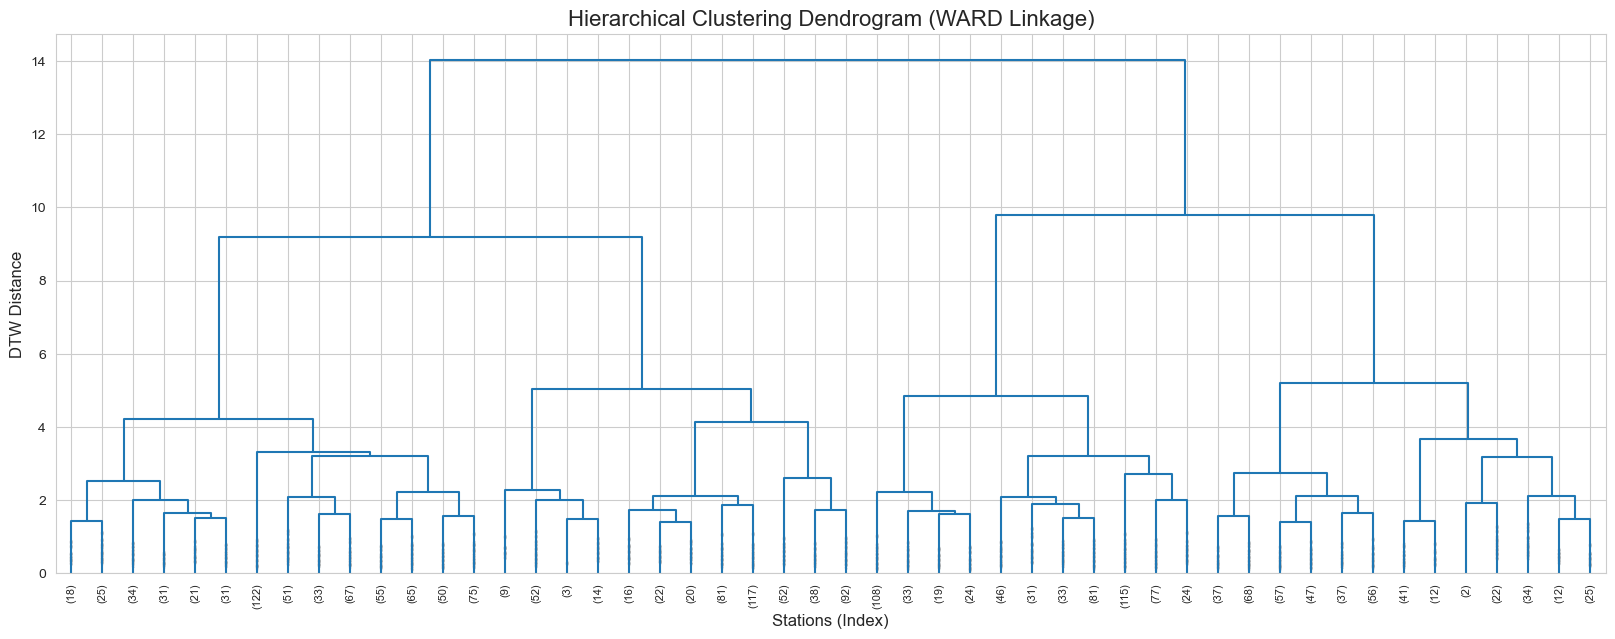

In [6]:
# Use 'ward' instead of 'average'
Z_weekday = linkage(dist_condensed_weekday, method='ward')

# Plot dendrogram
plt.figure(figsize=(20, 7))
plt.title('Hierarchical Clustering Dendrogram (WARD Linkage)', fontsize=16)
plt.xlabel('Stations (Index)', fontsize=12)
plt.ylabel('DTW Distance', fontsize=12)

dendrogram(
    Z_weekday,
    leaf_rotation=90.,  
    leaf_font_size=8.,
    truncate_mode='lastp',
    p=50,
    show_contracted=True,
    color_threshold=0
)
plt.show()

The use of the `'ward'` method not only performs better but also provides very clear cutting options:

1. Cutting at height 12 (2 clusters): This provides the most generalized separation. It indicates the existence of two primary station macro-types: a residential type and an office/workplace type.
2. Cutting at height 8 (4 clusters): In this scenario, each of the two previously described macro-types is further subdivided into two, revealing subtle behavioral differences within the broader residential and workplace categories.

Cutting lower would introduce additional clusters that would likely only add noise to the investigation, as there would be no substantial differences between these new station types.
Comparing this with the pre-cleaning clusters reveals significant differences. The distinctions are now much clearer. This improvement is likely due to the removal of leisure-oriented circular trips near parks or promenades. Previously, these trips distorted the actual utilitarian usage of nearby stations, creating artificial clusters or assigning erroneous characteristics to existing ones.

Given that both the 2-cluster and 4-cluster options appear viable, the spatial distribution of the stations will first be evaluated for coherence. Subsequently, a visual inspection will determine which partition offers the most valuable insights.

In [7]:
# Remove previous cluster labels column
df_signatures_weekday.drop(columns=['cluster_label'], inplace=True)

# Create new cluster labels using 'ward' linkage
# Level 1: General (K = 2)
K_general = 2
df_signatures_weekday['cluster_macro'] = fcluster(Z_weekday, t=K_general, criterion='maxclust')

# Level 2: Especific (K = 4)
K_especific = 4
df_signatures_weekday['cluster_micro'] = fcluster(Z_weekday, t=K_especific, criterion='maxclust')

# Comparation of cluster distributions
print("Cluster distribution (General - K=3):")
print(df_signatures_weekday['cluster_macro'].value_counts().sort_index())

print("\nCluster distribution (Especific - K=4):")
print(df_signatures_weekday['cluster_micro'].value_counts().sort_index())

Cluster distribution (General - K=3):
cluster_macro
1    1194
2    1041
Name: count, dtype: int64

Cluster distribution (Especific - K=4):
cluster_micro
1    678
2    516
3    591
4    450
Name: count, dtype: int64


The spatial division demonstrates coherence. Therefore, the visualization on the map will ultimately dictate the winning option. It should be noted that in the 4-cluster partition, the number of stations belonging to each cluster has barely changed from the previous analysis, suggesting the final outcome might be similar.

### Cluster Profiling

As in the initial analysis, the usage profiles will be displayed first to understand the behavior of each cluster, followed by a map visualization where stations are color-coded according to their assigned cluster.

In [8]:
def plot_cluster_profiles(df, n_clusters, cluster_name):
    # Get hours columns
    hour_cols = [c for c in df.columns if c.startswith('h_')]

    rows = (n_clusters // 2) + (n_clusters % 2)
    fig, axes = plt.subplots(rows, 2, figsize=(15, 4 * rows), sharex=False, sharey=True)
    axes = axes.flatten()

    palette = sns.color_palette("bright", n_clusters + 1)

    for k in range(1, n_clusters + 1):
        ax = axes[k-1]
        
        # Filter data for this cluster
        cluster_data = df[df[cluster_name] == k]
        
        # Plot a sample of individual stations
        sample = cluster_data.sample(min(100, len(cluster_data)), random_state=42)
        for _, row in sample.iterrows():
            ax.plot(range(24), row[hour_cols], color='gray', alpha=0.1, linewidth=0.5)
            
        # Plot the Centroid
        centroid = cluster_data[hour_cols].mean()
        ax.plot(range(24), centroid, color=palette[k-1], linewidth=3, label=f'Cluster {k}')
        
        ax.set_title(f'Cluster {k} ({len(cluster_data)} stations)', fontsize=14, fontweight='bold')
        ax.set_xticks(range(0, 24, 4))
        ax.grid(True, alpha=0.3)
        
    # Remove empty subplots if any
    for i in range(n_clusters, len(axes)):
        fig.delaxes(axes[i])
        
    plt.tight_layout(h_pad=2.0)
    plt.suptitle(f'Activity Profiles (K={n_clusters})', y=1.02, fontsize=18)
    plt.show()

In [11]:
CLUSTER_COLUMN_MACRO = 'cluster_macro'
NUM_CLUSTERS_MACRO = 2

CLUSTER_COLUMN_MICRO = 'cluster_micro'
NUM_CLUSTERS_MICRO = 4

target_crs = "EPSG:4326"

# Load data to plot stations
df_stations = pd.read_csv('../../data/processed/stations.csv')
nyc_map = gpd.read_file("../../data/raw/city/Borough_Boundaries_20260126.geojson")
nyc_streets = gpd.read_file("../../data/raw/city/Centerline_20260126.geojson")

df_stations['station_id'] = df_stations['station_id'].astype(str)

if df_signatures_weekday.index.name == 'station_id' or 'station_id' not in df_signatures_weekday.columns:
    df_signatures_weekday = df_signatures_weekday.reset_index()

df_signatures_weekday['start_station_id'] = df_signatures_weekday['start_station_id'].astype(str)

# Merge DataFrames
df_merged = df_stations.merge(
    df_signatures_weekday[['start_station_id', 'cluster_macro', 'cluster_micro']], 
    left_on='station_id', 
    right_on='start_station_id', 
    how='inner'
)

# Convert to GeoDataFrame
gdf_stations = gpd.GeoDataFrame(
    df_merged, 
    geometry=gpd.points_from_xy(df_merged['lng'], df_merged['lat']),
    crs=target_crs
)

if nyc_map.crs != target_crs: nyc_map = nyc_map.to_crs(target_crs)
if nyc_streets.crs != target_crs: nyc_streets = nyc_streets.to_crs(target_crs)
if gdf_stations.crs != target_crs: gdf_stations = gdf_stations.to_crs(target_crs)

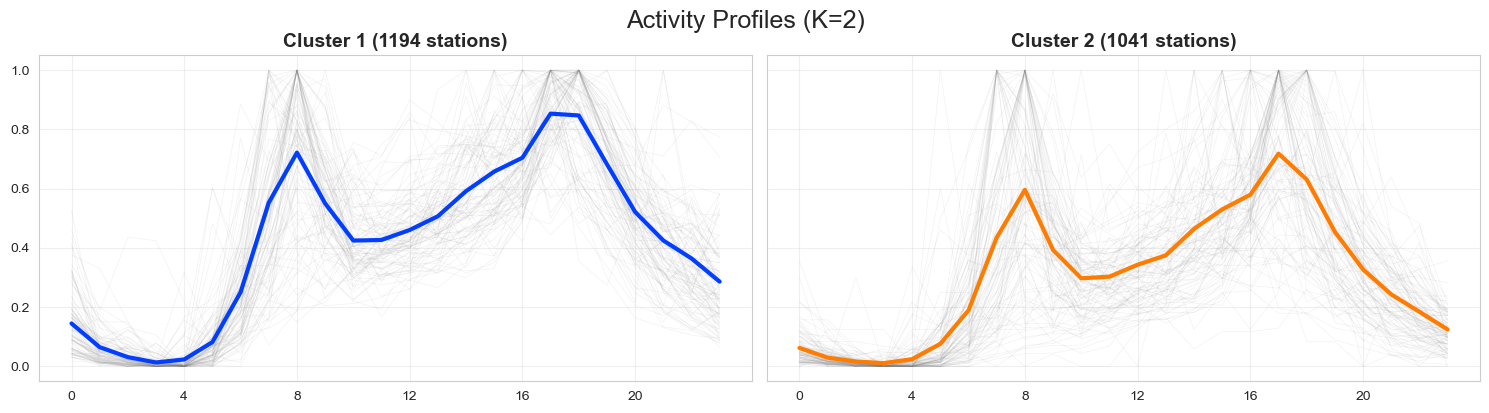

In [12]:
# Plot profiles for 2 clusters (General)
plot_cluster_profiles(df_signatures_weekday, 2, 'cluster_macro')

Looking at the profile for the 2-cluster division, it does not appear to generate distinct boundaries between station types. In both cases, demand peaks are observed during morning commute hours (leaving home for work) and evening commute hours (returning home from work). The primary difference seems to be volume: Type 1 stations experience higher overall usage than Type 2 stations, as evidenced by higher peak values.

These profile charts alone do not provide definitive conclusions about each type. Perhaps displaying the stations on a map will yield more concrete insights.

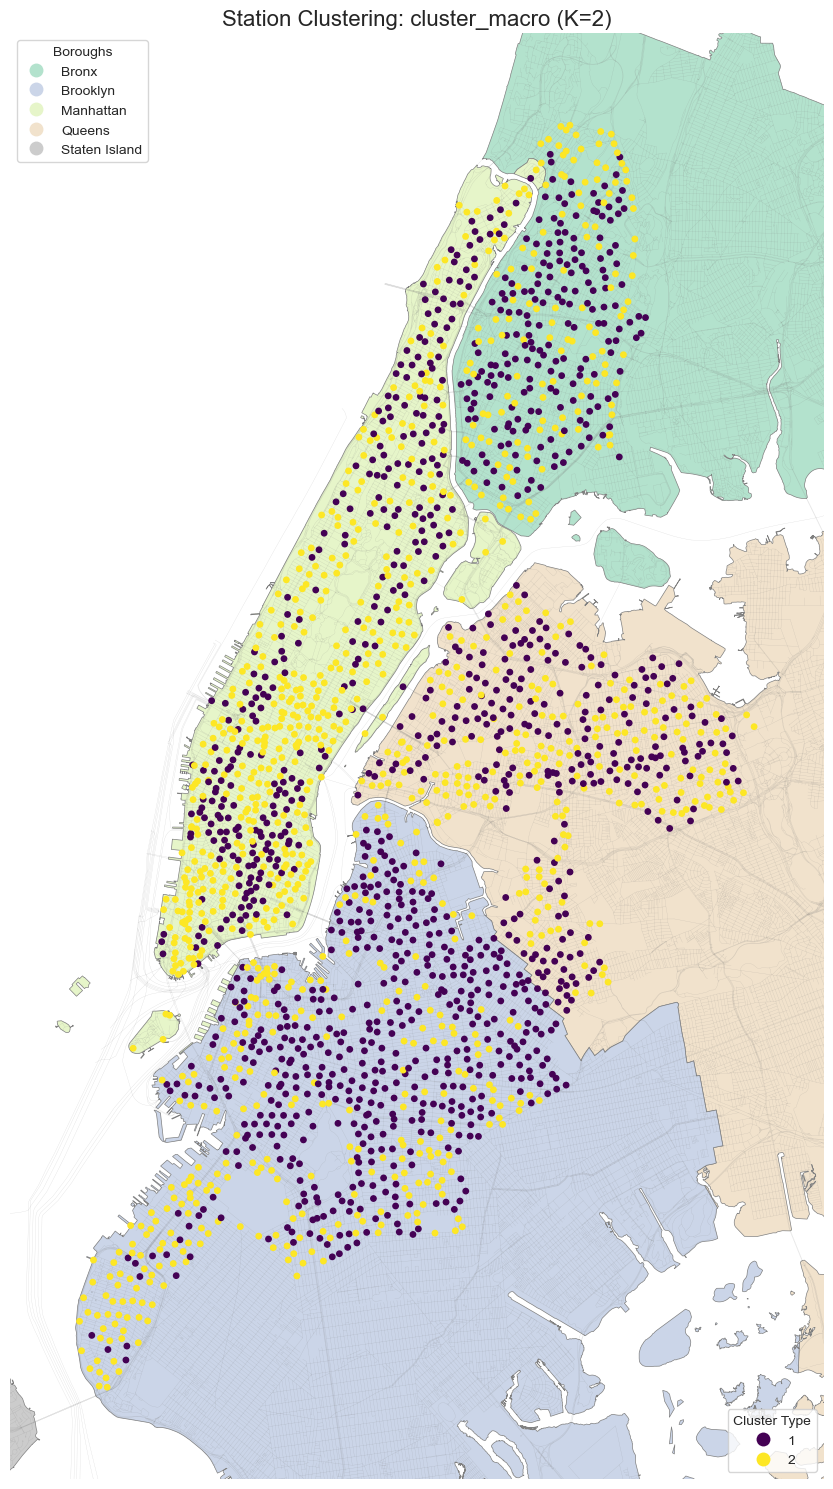

In [13]:
fig, ax = plt.subplots(figsize=(15, 15))

nyc_map.plot(
    ax=ax, 
    column='boroname',
    cmap='Pastel2',
    edgecolor='gray',
    linewidth=0.5,
    legend=True,
    legend_kwds={'loc': 'upper left', 'title': 'Boroughs'}
)

# Save the legend object to reuse later
leg1 = ax.get_legend()

nyc_streets.plot(
    ax=ax, 
    color='gray', 
    linewidth=0.2, 
    alpha=0.3,
    zorder=1
)

gdf_stations.plot(
    ax=ax, 
    column=CLUSTER_COLUMN_MACRO,
    cmap='viridis',
    markersize=15,
    alpha=1,
    legend=True,
    categorical=True,
    zorder=2,
    legend_kwds={'loc': 'lower right', 'title': 'Cluster Type'}
)

# Re-add the first legend (Boroughs)
ax.add_artist(leg1)

plt.title(f'Station Clustering: {CLUSTER_COLUMN_MACRO} (K={NUM_CLUSTERS_MACRO})', fontsize=16)
plt.axis('off')

minx, miny, maxx, maxy = gdf_stations.total_bounds
margin = 0.02
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)

plt.tight_layout()
plt.show()

Based on the geographical location of the stations in each cluster, the following conclusions can be drawn:

**Cluster 1 (Residential):** Being located primarily in peripheral neighborhoods and Upper Manhattan, typical bedroom communities with high population density, these stations are predominantly used by commuters starting their journey to work.

**Cluster 2 (Workplace and Leisure):** Concentrated mostly in the Financial District, around Central Park, and Midtown, these areas boast a high density of workplaces alongside major leisure destinations like Central Park or the waterfront promenades in Bay Ridge, Brooklyn.

However, this binary division appears too generalized and fails to accurately capture the nuanced variety of station typologies. The experiments will now be repeated using 4 clusters to determine if finer distinctions emerge.

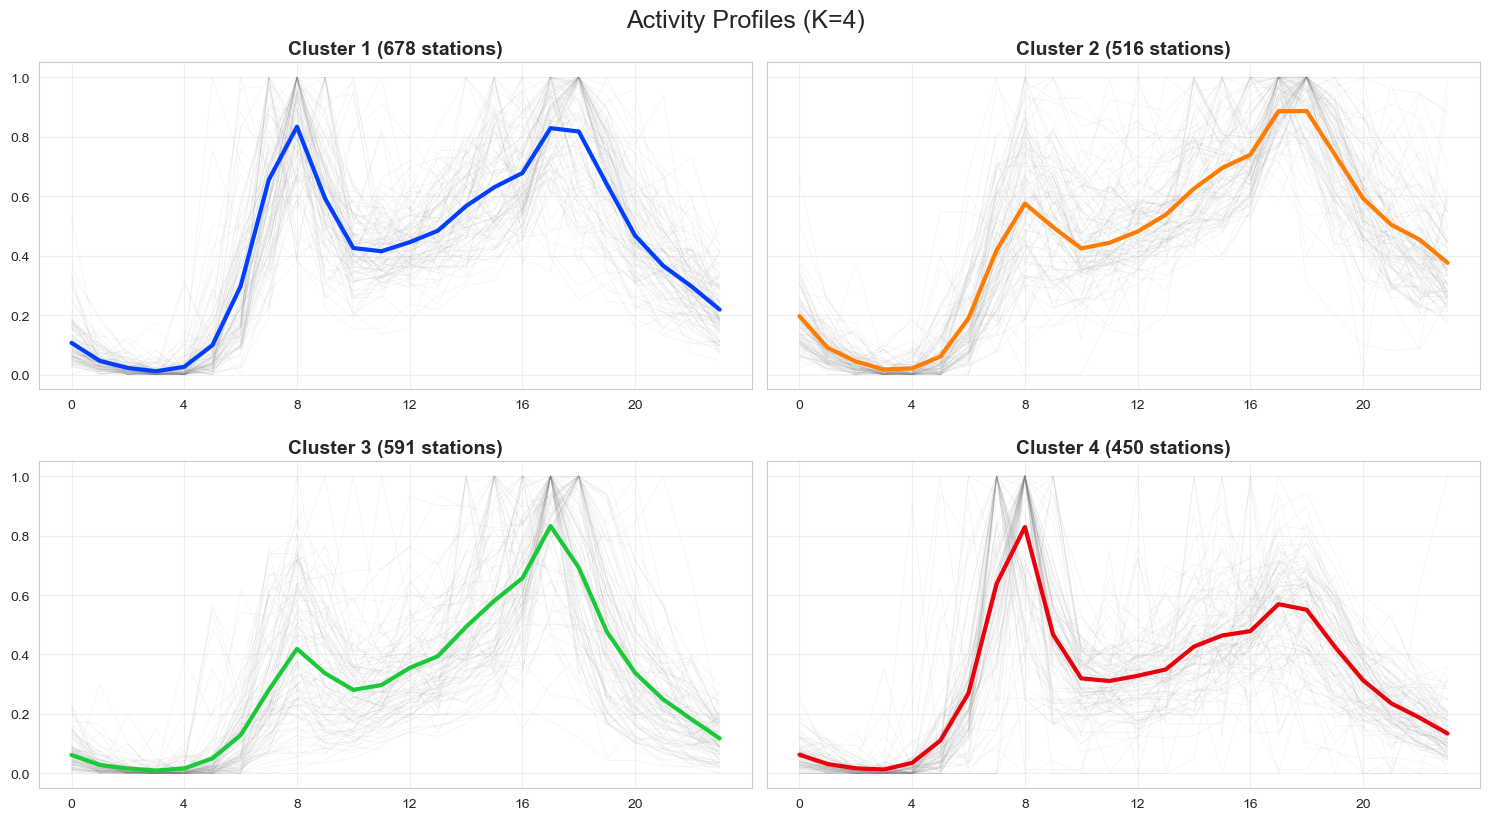

In [15]:
# Plot profiles for 4 clusters (Balanced)
plot_cluster_profiles(df_signatures_weekday, 4, 'cluster_micro')

The differences based on usage profiles are now much clearer. Two clusters, in particular, are highly differentiated: Cluster 3 and Cluster 4. Cluster 3 shows a low volume of morning departures but a massive spike during the evening commute (leaving work). The exact opposite occurs with Cluster 4, which exhibits a massive morning departure peak and very low usage in the afternoon.

Regarding the first two clusters, Cluster 1 displays nearly identical peaks in both the morning and afternoon. This implies stations located near residential areas that also contain a significant mix of offices and local businesses. Cluster 2 likely represents leisure zones, as its usage peak is reached at 5:00 PM and sustains until 6:00 PM, indicating continued use even after standard working hours.

To confirm these hypotheses, the stations will be mapped to verify if their usage profiles align with the characteristics of their geographical locations.

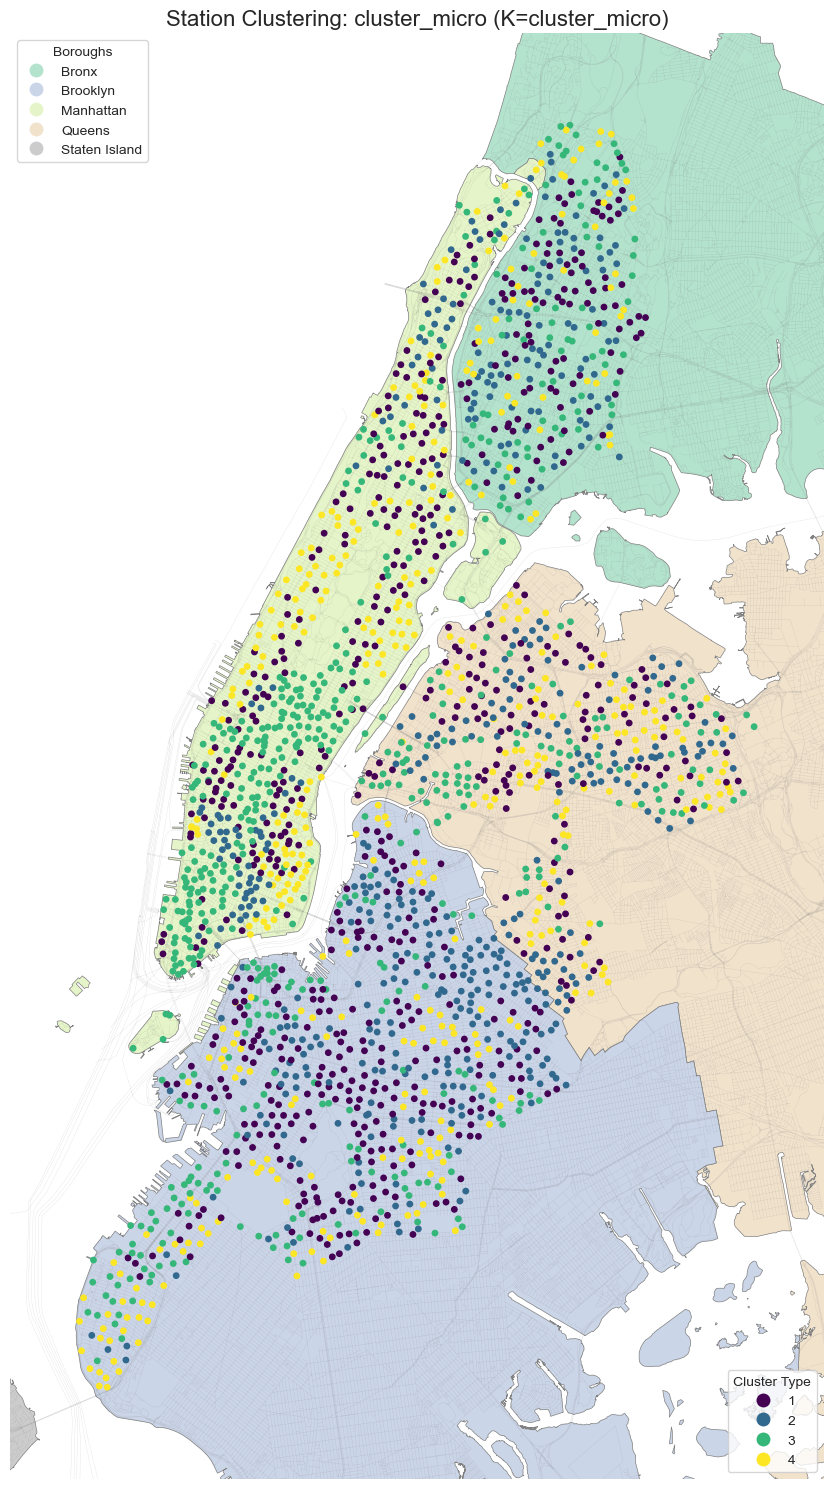

In [16]:
fig, ax = plt.subplots(figsize=(15, 15))

nyc_map.plot(
    ax=ax, 
    column='boroname',
    cmap='Pastel2',
    edgecolor='gray',
    linewidth=0.5,
    legend=True,
    legend_kwds={'loc': 'upper left', 'title': 'Boroughs'}
)

# Save the legend object to reuse later
leg1 = ax.get_legend()

nyc_streets.plot(
    ax=ax, 
    color='gray', 
    linewidth=0.2, 
    alpha=0.3,
    zorder=1
)

gdf_stations.plot(
    ax=ax, 
    column=CLUSTER_COLUMN_MICRO,
    cmap='viridis',
    markersize=15,
    alpha=1,
    legend=True,
    categorical=True,
    zorder=2,
    legend_kwds={'loc': 'lower right', 'title': 'Cluster Type'}
)

# Re-add the first legend (Boroughs)
ax.add_artist(leg1)

plt.title(f'Station Clustering: {CLUSTER_COLUMN_MICRO} (K={CLUSTER_COLUMN_MICRO})', fontsize=16)
plt.axis('off')

minx, miny, maxx, maxy = gdf_stations.total_bounds
margin = 0.02
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)

plt.tight_layout()
plt.show()

Visualizing the stations on the map confirms several of the hypotheses drawn from the profiles.

**Cluster 3 (Workplace Zones):** These stations can clearly be identified as areas with a high concentration of offices and corporate headquarters. They are located primarily from the Financial District in Manhattan, extending up through Midtown towards Central Park.

**Cluster 4 (High-Density Residential):** The typology of these stations is immediately apparent based on their location on Manhattan Island. They are clustered in well-known residential neighborhoods, such as the Lower East Side and the Upper West Side.

These were the most clearly differentiated clusters, easily confirmed through visual inspection. An attempt will now be made to explain the remaining two types, which possess less polarized usage profiles.

**Cluster 2 (Leisure / Intra-neighborhood Mobility):** This cluster was identified based on its usage profile peaking in the late afternoon and evening, suggesting leisure-oriented travel. However, it does not solely represent stations used to access entertainment hubs, these stations are also heavily used for transportation within the neighborhood itself. The leisure aspect is evident in Manhattan, with a high concentration in neighborhoods like Soho and Chinatown, and in Brooklyn neighborhoods like Bushwick and Williamsburg, renowned for their vibrant dining and retail scenes. Nevertheless, the uniform distribution of this cluster type across The Bronx suggests these stations also serve as a crucial mode of intra-neighborhood mobility.

Finally, **Cluster 1 (Mixed-Use / Transit Hubs):** The profile already indicated that its usage would not be as polarized as the others. It is considered mixed-use because it exhibits high volume during both morning and afternoon peaks. However, unlike the other clusters, mapping these stations reveals they are predominantly located on the periphery of Manhattan, near the bridges connecting it to the outer boroughs. This implies that many commuters disembark from their primary mode of public transit upon entering Manhattan and use bicycles to complete the "last mile" of their journey to work (or to connect to another transit hub).

### Final Conclusion

After evaluating both options, it is clear that $K = 4$ provides the most accurate and meaningful cluster differentiation. The analysis conducted prior to the removal of circular trips reached the exact same conclusion, identifying the same broad station typologies. This was anticipated, a visual comparison of the mapped clusters before and after the data cleaning reveals that the stations remained divided in practically the same manner, maintaining similar proportions across the clusters.

Consequently, it can be concluded that the removal of circular trips did not alter the fundamental number of station typologies. Instead, it reaffirmed the validity of the 4-cluster division while simultaneously refining it, reassigning specific stations to clusters that better match their true underlying usage patterns now that the "noise" of circular leisure trips has been removed.

## Weekend Analysis

The same methodology will be applied to the weekend dataset. However, massive structural changes are not anticipated, given that the vast majority of the removed circular trips occurred during weekdays.

### Dendrogram

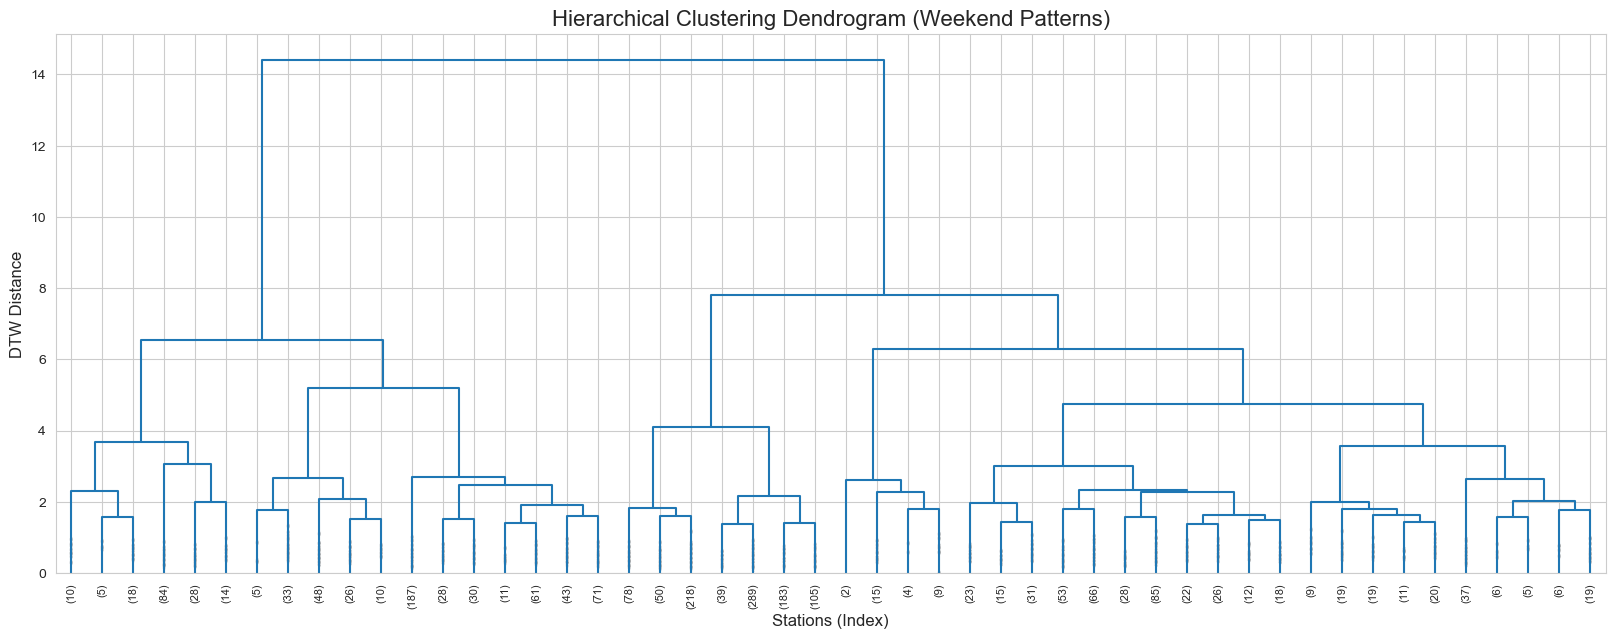

In [17]:
dist_condensed_weekend = squareform(dtw_matrix_weekend)

# Compute hierarchical clustering
Z_weekend = linkage(dist_condensed_weekend, method='ward')

# Plot dendrogram
plt.figure(figsize=(20, 7))
plt.title('Hierarchical Clustering Dendrogram (Weekend Patterns)', fontsize=16)
plt.xlabel('Stations (Index)', fontsize=12)
plt.ylabel('DTW Distance', fontsize=12)

dendrogram(
    Z_weekend,
    leaf_rotation=90.,  
    leaf_font_size=8.,
    truncate_mode='lastp',
    p=50,
    show_contracted=True,
    color_threshold=0
)
plt.show()

In this scenario, the dendrogram is practically identical to the one generated from the uncleaned dataset. Although a separation into two large groups ($K = 2$) is mathematically possible, the previous analysis demonstrated that this binary division is too generalized and lacks analytical value, therefore, it will not be evaluated here.
When dividing into 3 clusters, it was previously observed that while better than 2, it lacked precision, and 4 clusters proved to be a much stronger option.

For this reason, the partitions will be evaluated at $K = 4$ (cutting approx. at 6.25) and $K = 5$ (cutting at 6). This is because, in the initial study, shorter vertical lines in the dendrogram indicated that further divisions were somewhat "artificial" due to high similarity between the resulting clusters. However, in this new cleaned dataset, cutting at approximately 6.25 to yield 4 clusters reveals that the rightmost cluster can be cleanly divided into two distinct larger subgroups. While this might introduce noise, it is worth investigating to see if the data cleaning has uncovered a legitimately distinct new behavioral cluster.

In [18]:
# Create new cluster labels using 'ward' linkage
# Level 1: General (K = 4)
K_general = 4
df_signatures_weekend['cluster_macro'] = fcluster(Z_weekend, t=K_general, criterion='maxclust')

# Level 2: Balanced (K = 5)
K_balanced = 5
df_signatures_weekend['cluster_micro'] = fcluster(Z_weekend, t=K_balanced, criterion='maxclust')

# Comparation of cluster distributions
print("Cluster distribution (General - K=4):")
print(df_signatures_weekend['cluster_macro'].value_counts().sort_index())

print("\nCluster distribution (Especific - K=5):")
print(df_signatures_weekend['cluster_micro'].value_counts().sort_index())

Cluster distribution (General - K=4):
cluster_macro
1    159
2    553
3    962
4    560
Name: count, dtype: int64

Cluster distribution (Especific - K=5):
cluster_micro
1    159
2    553
3    962
4     30
5    530
Name: count, dtype: int64


The cluster distribution reveals a crucial finding: whereas in the previous 4-cluster study, one cluster dominated the vast majority of stations while anothers contained very few, the stations are now distributed much more evenly. This suggests that while the data cleaning may not have changed the total number of typologies, it has profoundly impacted how stations are categorized into them. Furthermore, moving to $K = 5$ simply splits a few stations away from cluster 4 into their own isolated group. This highly specific division might prove valuable when analyzing the profiles and mapping the stations.

In [19]:
CLUSTER_COLUMN_MACRO = 'cluster_macro'
NUM_CLUSTERS_MACRO = 4

CLUSTER_COLUMN_MICRO = 'cluster_micro'
NUM_CLUSTERS_MICRO = 5

target_crs = "EPSG:4326"

if df_signatures_weekend.index.name == 'station_id' or 'station_id' not in df_signatures_weekend.columns:
    df_signatures_weekend = df_signatures_weekend.reset_index()

df_signatures_weekend['start_station_id'] = df_signatures_weekend['start_station_id'].astype(str)

# Merge DataFrames
df_merged = df_stations.merge(
    df_signatures_weekend[['start_station_id', 'cluster_macro', 'cluster_micro']], 
    left_on='station_id', 
    right_on='start_station_id', 
    how='inner'
)

# Convert to GeoDataFrame
gdf_stations = gpd.GeoDataFrame(
    df_merged, 
    geometry=gpd.points_from_xy(df_merged['lng'], df_merged['lat']),
    crs=target_crs
)

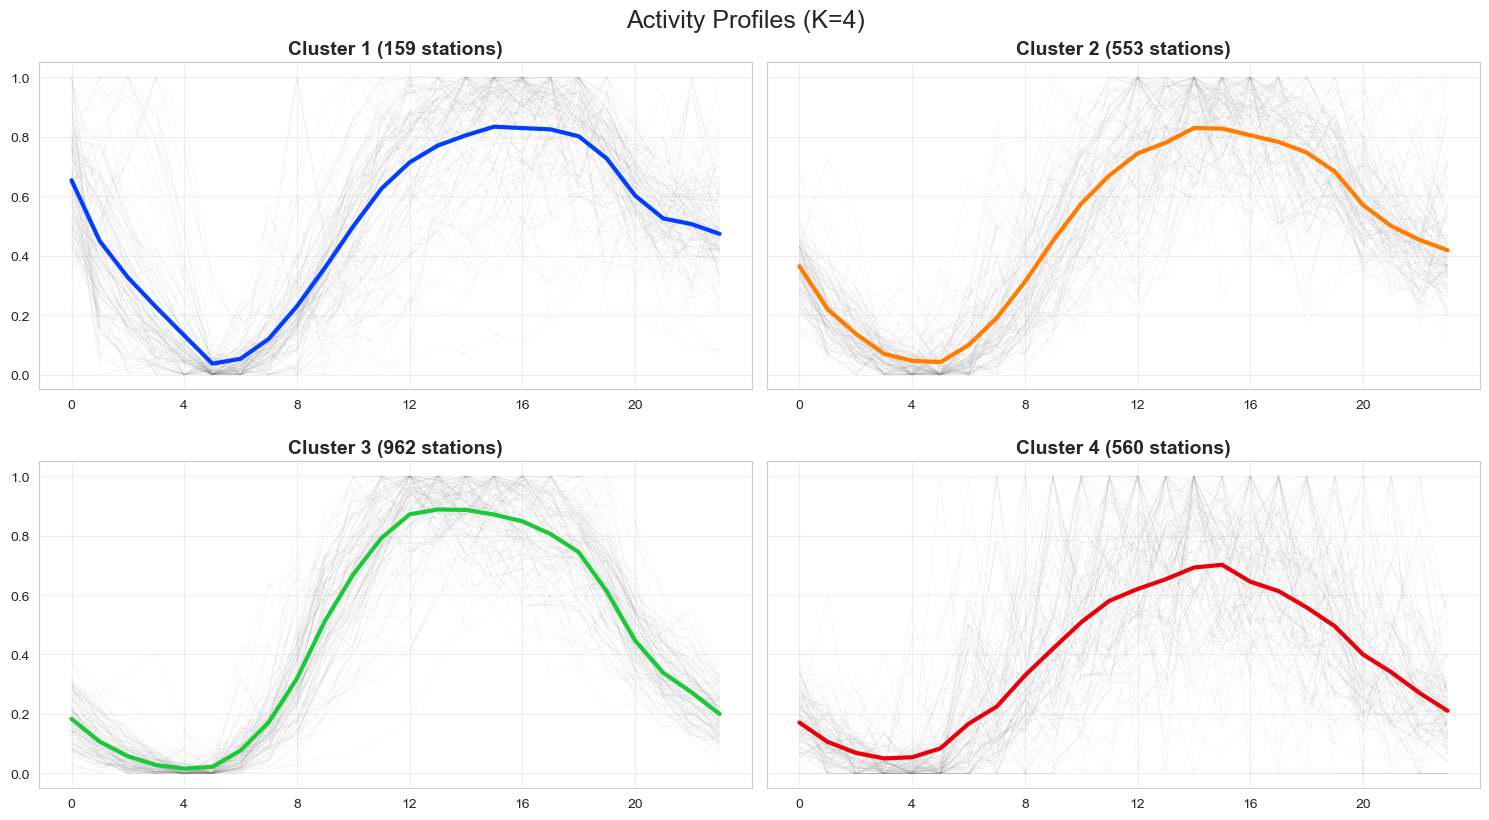

In [20]:
# Plot profiles for 4 clusters (General)
plot_cluster_profiles(df_signatures_weekend, 4, 'cluster_macro')

With the 4-cluster division, the profile charts alone are insufficient to definitively label each group. However, a notable anomaly is visible in Cluster 1: usage during midnight and early morning hours is significantly higher than in the other clusters. This strongly suggests that these stations are located in areas with vibrant nightlife. Mapping the stations is expected to clarify these distinctions further.

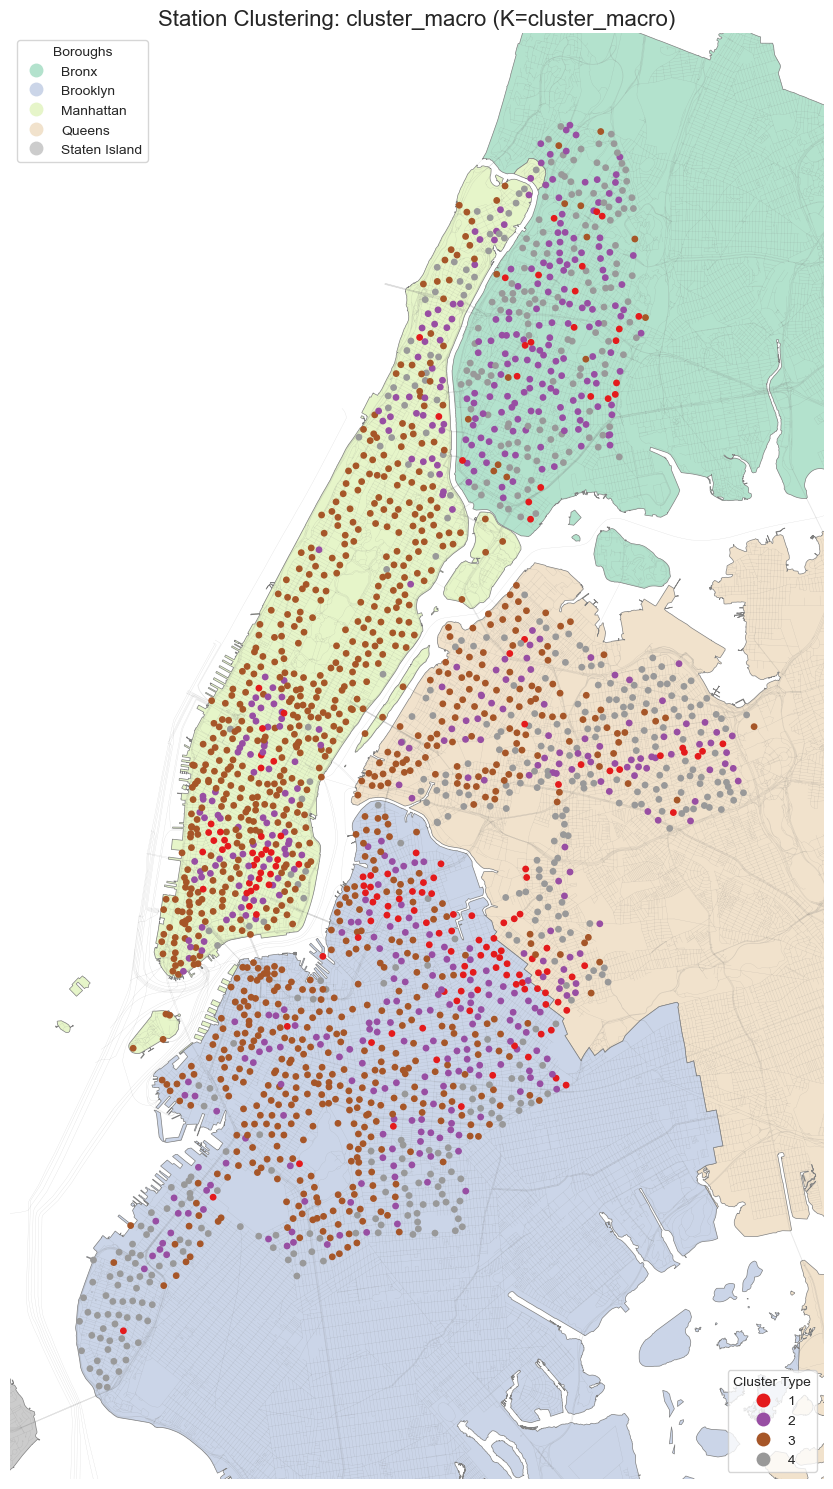

In [23]:
fig, ax = plt.subplots(figsize=(15, 15))

nyc_map.plot(
    ax=ax, 
    column='boroname',
    cmap='Pastel2',
    edgecolor='gray',
    linewidth=0.5,
    legend=True,
    legend_kwds={'loc': 'upper left', 'title': 'Boroughs'}
)

# Save the legend object to reuse later
leg1 = ax.get_legend()

nyc_streets.plot(
    ax=ax, 
    color='gray', 
    linewidth=0.2, 
    alpha=0.3,
    zorder=1
)

gdf_stations.plot(
    ax=ax, 
    column=CLUSTER_COLUMN_MACRO,
    cmap='Set1',
    markersize=15,
    alpha=1,
    legend=True,
    categorical=True,
    zorder=2,
    legend_kwds={'loc': 'lower right', 'title': 'Cluster Type'}
)

# Re-add the first legend (Boroughs)
ax.add_artist(leg1)

plt.title(f'Station Clustering: {CLUSTER_COLUMN_MACRO} (K={CLUSTER_COLUMN_MACRO})', fontsize=16)
plt.axis('off')

minx, miny, maxx, maxy = gdf_stations.total_bounds
margin = 0.02
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)

plt.tight_layout()
plt.show()

As hypothesized, while 4 clusters remain a mathematically sound choice, the spatial distribution of the stations has completely transformed. Previously, the vast majority of stations were classified as Type 4, now Type 3 is the most populous cluster.

The hypothesis regarding Cluster 1 is confirmed: these are **Nightlife** stations, heavily concentrated in Manhattan neighborhoods like Soho and Little Italy, and Brooklyn neighborhoods like Williamsburg and Bushwick, areas renowned for their density of bars and restaurants.

Cluster 2 remains primarily characterized by **Commercial and Tourist Leisure**, concentrated in Midtown Manhattan and scattered across notable points of interest in the other boroughs.

Clusters 3 and 4 have experienced the most radical transformations. Previously, Cluster 4 represented typical residential use, while Cluster 3 contained peripheral stations with minimal usage. Now, Cluster 3 is the largest group, clearly representing the standard **Residential Cluster**. Cluster 4 exhibits a key characteristic: it is almost entirely absent from Manhattan, yet it is distributed homogeneously across the outer boroughs. This indicates that these stations are primarily used for transportation within those outer neighborhoods, classifying it as an **Intra-neighborhood Mobility** cluster.

Compared to the pre-cleaning study, although the number of identified station typologies remains the same, Clusters 3 and 4 have undergone a radical redefinition. Therefore, it can be firmly stated that the removal of circular trips has had a profound and highly effective impact on revealing true weekend mobility patterns.

The partition dividing Cluster 4 into two separate groups (resulting in 5 clusters overall) will now be examined to determine if it yields any analytically valuable characteristics.

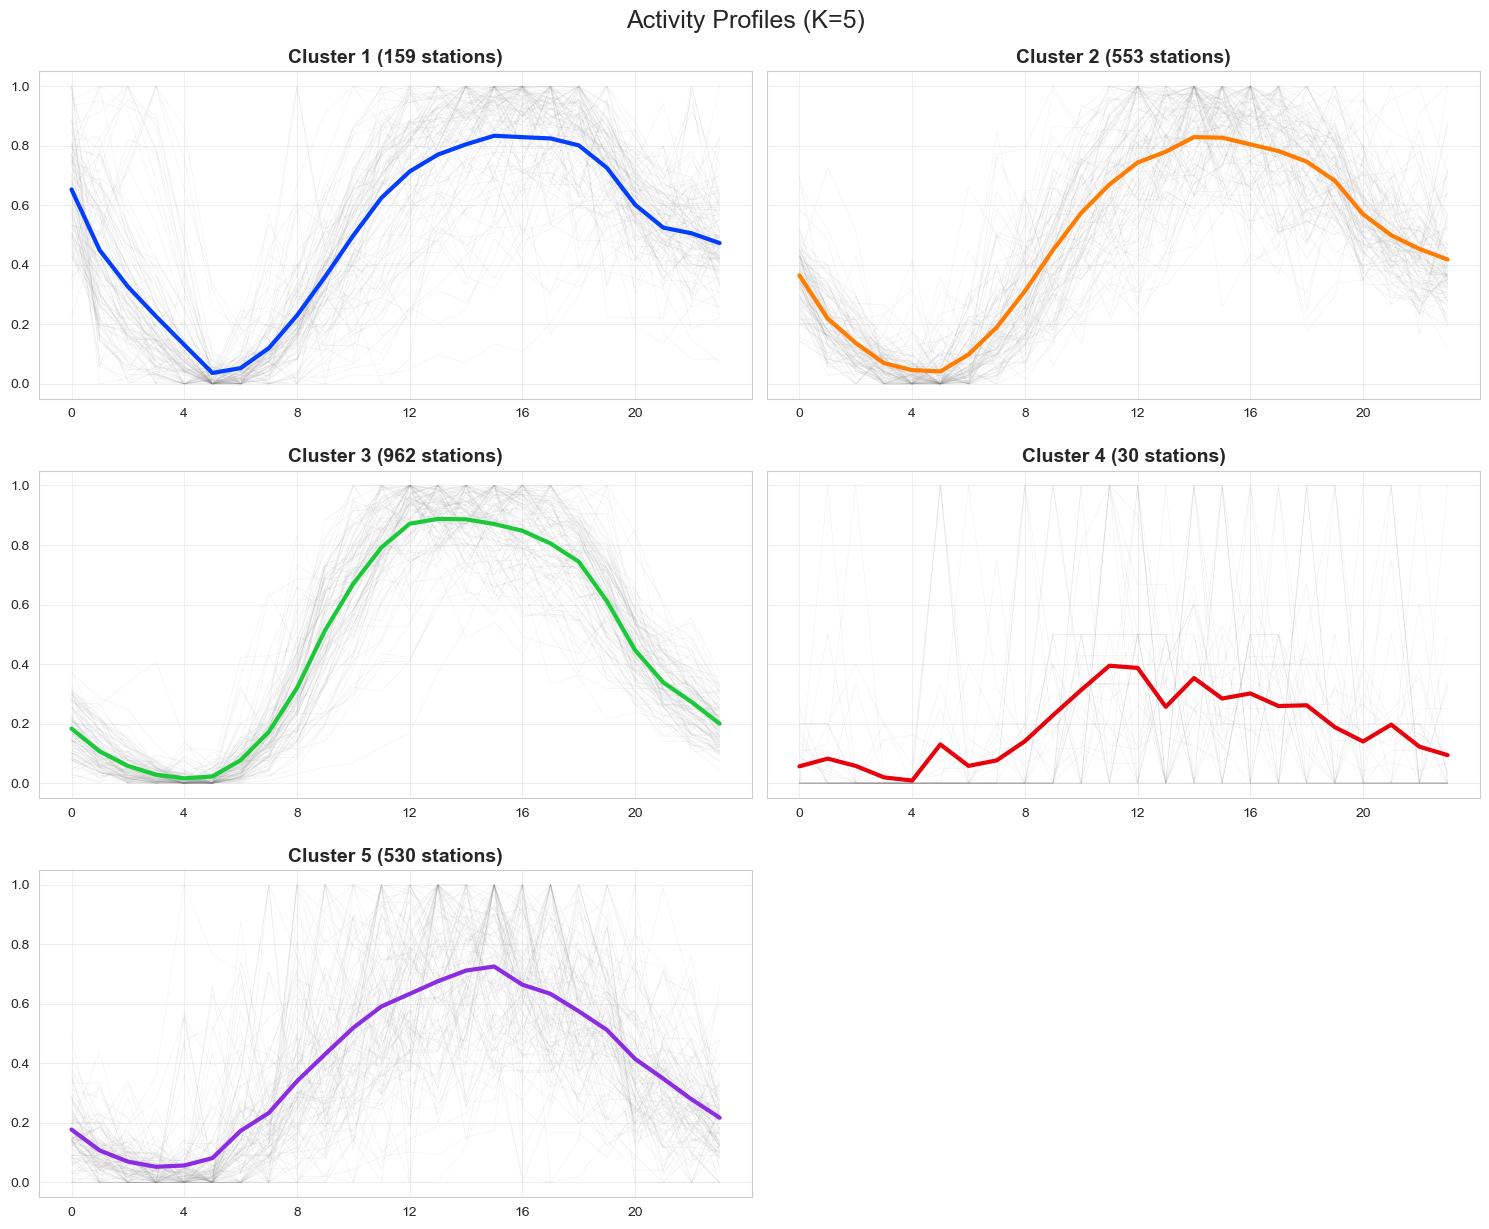

In [24]:
# Plot profiles for 5 clusters (Micro)
plot_cluster_profiles(df_signatures_weekend, 5, 'cluster_micro')

It appears that this further division has successfully isolated what were termed "ghost stations" in the previous study (stations located in the furthest reaches of the outer boroughs that see virtually no usage during the weekend). A visual inspection of the map will confirm if this isolation holds true geographically.

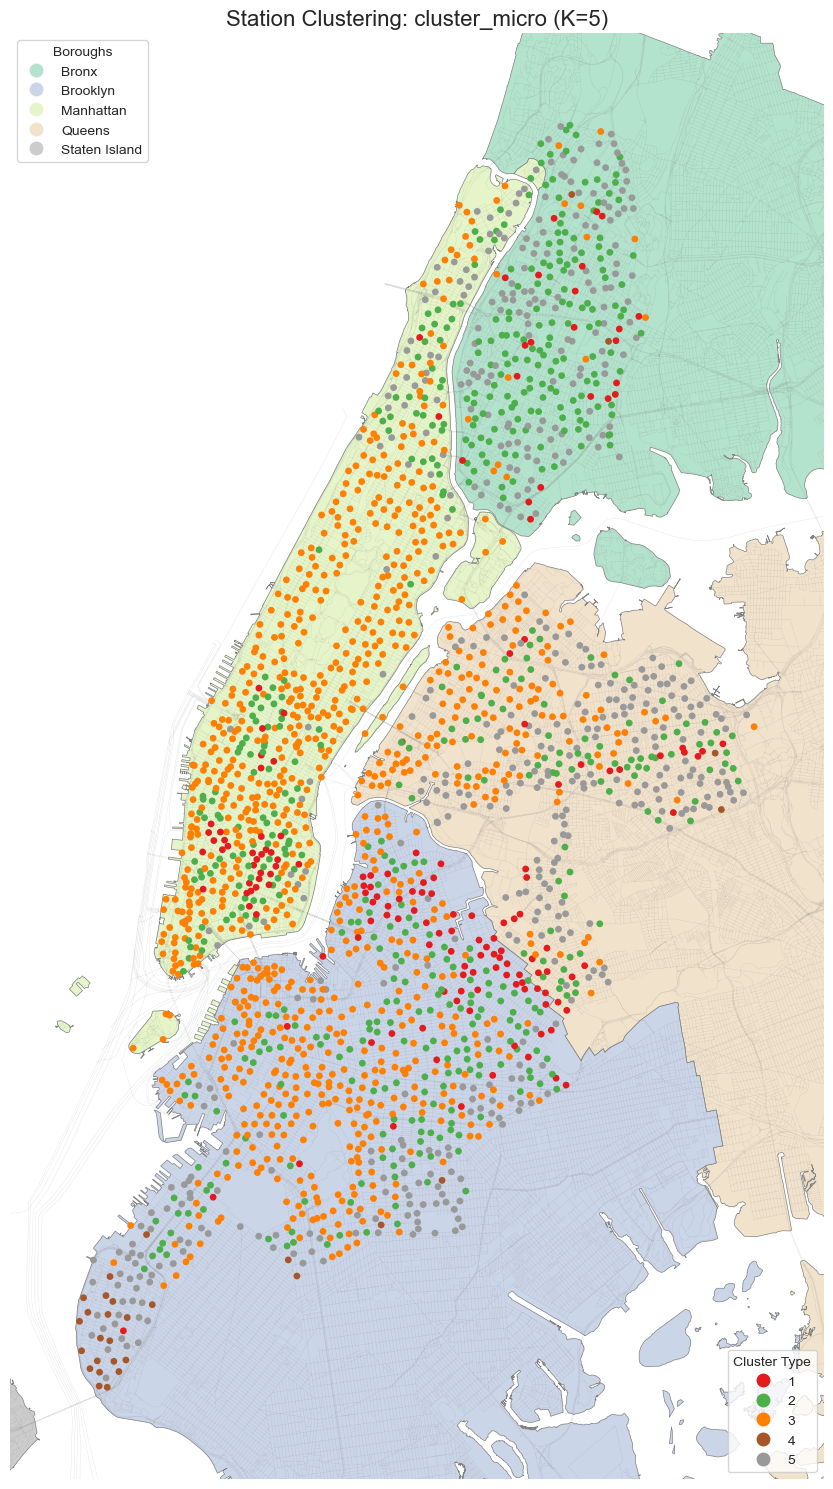

In [25]:
fig, ax = plt.subplots(figsize=(15, 15))

nyc_map.plot(
    ax=ax, 
    column='boroname',
    cmap='Pastel2',
    edgecolor='gray',
    linewidth=0.5,
    legend=True,
    legend_kwds={'loc': 'upper left', 'title': 'Boroughs'}
)

# Save the legend object to reuse later
leg1 = ax.get_legend()

nyc_streets.plot(
    ax=ax, 
    color='gray', 
    linewidth=0.2, 
    alpha=0.3,
    zorder=1
)

gdf_stations.plot(
    ax=ax, 
    column=CLUSTER_COLUMN_MICRO,
    cmap='Set1',
    markersize=15,
    alpha=1,
    legend=True,
    categorical=True,
    zorder=2,
    legend_kwds={'loc': 'lower right', 'title': 'Cluster Type'}
)

# Re-add the first legend (Boroughs)
ax.add_artist(leg1)

plt.title(f'Station Clustering: {CLUSTER_COLUMN_MICRO} (K={NUM_CLUSTERS_MICRO})', fontsize=16)
plt.axis('off')

minx, miny, maxx, maxy = gdf_stations.total_bounds
margin = 0.02
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)

plt.tight_layout()
plt.show()

Indeed, as the profile chart suggested, splitting Cluster 4 to create the new Clusters 4 and 5 served exclusively to isolate the **Ghost Stations** into their own distinct group (Cluster 4). These are stations with practically zero weekend demand. Geographically, they are heavily concentrated in the Bay Ridge area of Brooklyn. Notably, despite the proximity of a waterfront promenade, the bikesharing infrastructure in this specific area remains largely unused on weekends.

### Final Conclusion

After evaluating both alternatives, the 5-cluster model is determined to be the most optimal for the final analysis. Consistent with the methodological criteria established in the pre-cleaning study, this segmentation provides superior analytical value by successfully isolating stations with practically non-existent demand into a distinct minority group. Maintaining this configuration allows for the separation of these "ghost stations" from other peripheral infrastructure that does maintain active intra-neighborhood mobility. This ensures a much more precise, detailed, and operationally accurate snapshot of the system's reality during the weekend.

## Post-Cleaning Clustering Conclusion

Re-executing the clustering analysis yielded different outcomes depending on whether weekday or weekend trips were analyzed. For weekdays, this new study confirmed that the 4-cluster partition remains the most accurate representation; therefore, the data cleaning process did not disrupt the foundational typologies, which makes sense given that circular leisure trips are less prevalent during the workweek.

However, the impact on the weekend analysis was profound. Although the absolute volume of removed trips might have been lower compared to weekdays, these circular trips constituted a significant proportion of weekend activity. Consequently, their removal triggered massive shifts in the station clustering. Firstly, a major geographic and typological reorganization of the stations occurred. While the previous study was dominated by a single massive cluster with three minor ones, the new 4-cluster model shows a much more balanced and realistic distribution. Furthermore, introducing the fifth cluster successfully pinpointed stations with near zero weekend usage. Therefore, it is confirmed that for weekend mobility, re-executing the analysis post-cleaning brought about substantial and necessary corrections.

In conclusion, the final data cleaning phase, specifically the removal of non-strict circular trips, was highly successful. The resulting clusters are significantly more precise, eliminating behavioral noise and reflecting the true urban mobility reality of the bikesharing system far better than the previous iterations.